# Principal Component Analysis - PCA

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [18]:
from sklearn import decomposition

### Loading the data

In [19]:
X_train = pd.read_csv('data/csv/X_train')
X_val = pd.read_csv('data/csv/X_val')
X_test = pd.read_csv('data/csv/X_test')

y_train = pd.read_csv('data/csv/y_train')
y_val = pd.read_csv('data/csv/y_val')
y_test = pd.read_csv('data/csv/y_test')

## PCA

In [20]:
# for visualisation purposes
number_of_components = 2

In [21]:
pca = decomposition.PCA(n_components=number_of_components)

In [22]:
# temporary, removing y from X_train
X_train_without_activities = X_train.drop(["Activity", "ActivityName"], axis=1)
X_val_without_activities = X_val.drop(["Activity", "ActivityName"], axis=1)
X_test_without_activities = X_test.drop(["Activity", "ActivityName"], axis=1)

In [23]:
pca.fit(X_train_without_activities)

X_train_pca = pca.transform(X_train_without_activities)
X_val_pca = pca.transform(X_val_without_activities)
X_test_pca = pca.transform(X_test_without_activities)

### Visualisation PCA

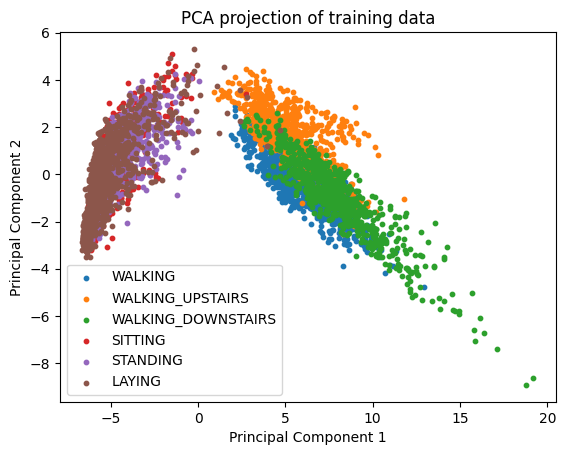

In [24]:
y = y_train.to_numpy().ravel()

activity_labels = {
    1: "WALKING",
    2: "WALKING_UPSTAIRS",
    3: "WALKING_DOWNSTAIRS",
    4: "SITTING",
    5: "STANDING",
    6: "LAYING"
}

for i in activity_labels:
    plt.scatter(
        X_train_pca[y == i, 0],
        X_train_pca[y == i, 1],
        label=activity_labels[i],
        s=10
    )

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA projection of training data")
plt.legend()
plt.savefig('images/pca')
plt.show()

In [25]:
# we can see some separation of activities

In [26]:
# total explained variance by the PCA
np.sum(pca.explained_variance_ratio_)

np.float64(0.6738249971255296)

## Kernelized PCA

In [27]:
kpca = decomposition.KernelPCA(n_components=number_of_components, kernel='rbf', gamma=0.1)

In [28]:
kpca.fit(X_train_without_activities)

X_train_kpca = kpca.transform(X_train_without_activities)
X_val_kpca = kpca.transform(X_val_without_activities)
X_test_kpca = kpca.transform(X_test_without_activities)

### Visualisation KPCA

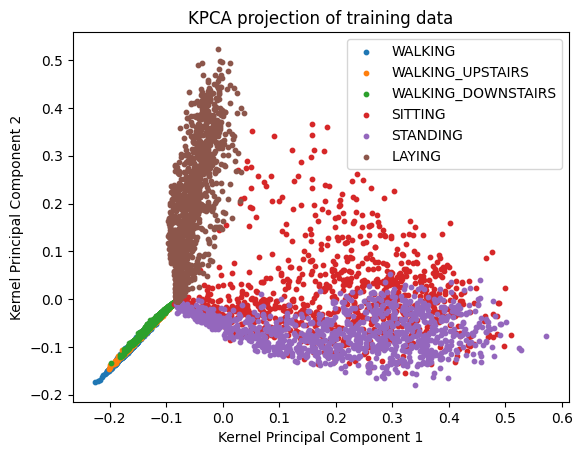

In [29]:
for i in activity_labels:
    plt.scatter(
        X_train_kpca[y == i, 0],
        X_train_kpca[y == i, 1],
        label=activity_labels[i],
        s=10
    )

plt.xlabel("Kernel Principal Component 1")
plt.ylabel("Kernel Principal Component 2")
plt.title("KPCA projection of training data")
plt.legend()
plt.savefig('images/kpca')
plt.show()

In [30]:
# again, separation between some classes can be spotted

## Exploring the number of components

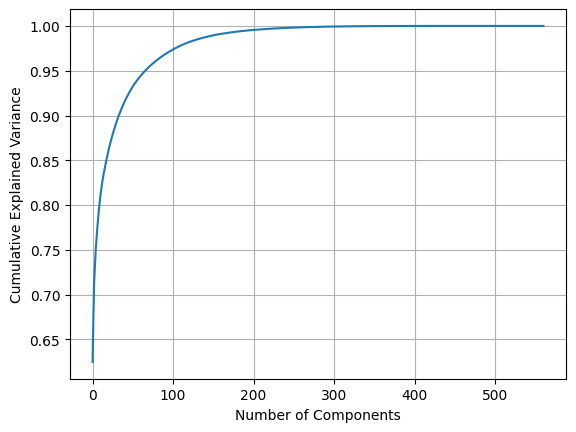

In [31]:
pca_full = decomposition.PCA()
pca_full.fit(X_train_without_activities)

plt.plot(np.cumsum(pca_full.explained_variance_ratio_))
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.grid()
plt.savefig('images/ncomp')
plt.show()

In [32]:
# this helps us understand the tradeoff: variance vs. number of components